In [250]:
import torch
from torch import nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from torchmetrics.classification import BinaryAccuracy, MulticlassAccuracy
import numpy as np

In [251]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


In [252]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [253]:
accuracy_fn = BinaryAccuracy(threshold=0.5).to(device)

Binary Classification dataset

In [254]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

In [255]:
data_df = pd.DataFrame({
  "X1": X[:, 0],
  "X2": X[:, 1],
  "Label": y
}) 

data_df[:10]

,X1,X2,Label
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0
5,0.662510,-0.084356,1
6,0.274510,-0.189904,1
7,-0.115556,0.535912,1
8,1.572369,-0.335447,1
9,0.763990,0.962359,0


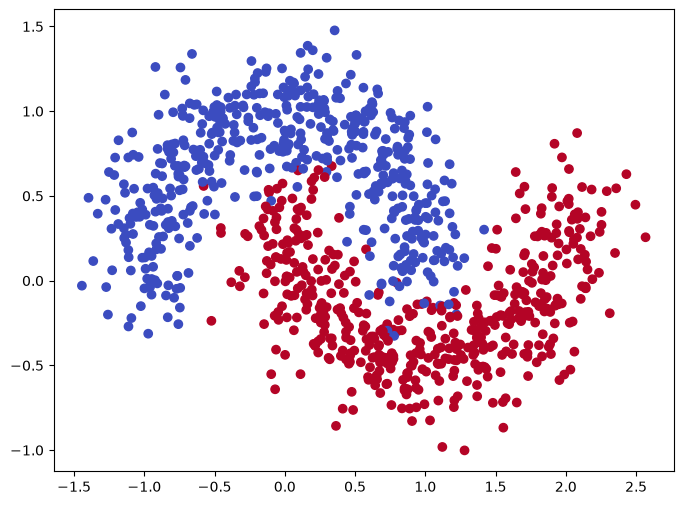

In [256]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)

In [257]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [258]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)


(800, 200, 800, 200)

In [259]:
class BinaryClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer = nn.Sequential(
      nn.Linear(in_features=2, out_features=10),
      nn.ReLU(),
      nn.Linear(in_features=10, out_features=10),
      nn.ReLU(),
      nn.Linear(in_features=10, out_features=1)
    ).to(device)

  def forward(self, x):
    return self.linear_layer(x)

In [260]:
model_binary = BinaryClassificationModel()

model_binary

BinaryClassificationModel(
  (linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [261]:
logits = model_binary(X_test.to(device)).squeeze()

with torch.inference_mode():
  y_pred = torch.round(torch.sigmoid(logits))

y_pred[:5]

tensor([1., 1., 0., 1., 0.], device='cuda:0')

In [262]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_binary.parameters(), lr=0.1)

In [263]:
torch.manual_seed(42)

epochs = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_binary.train()

  y_logits = model_binary(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_binary.eval()

  with torch.inference_mode():
    test_logits = model_binary(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 100 == 0:
    print(f"Epoch : {epoch} | Loss : {loss:.5f} | Acc : {acc:.5f}% | Test Loss : {test_loss:.5f} | test Acc : {test_acc:.5f}%")

Epoch : 0 | Loss : 0.69494 | Acc : 0.39875% | Test Loss : 0.69399 | test Acc : 0.50500%
Epoch : 100 | Loss : 0.40633 | Acc : 0.80625% | Test Loss : 0.42149 | test Acc : 0.77500%
Epoch : 200 | Loss : 0.28933 | Acc : 0.87250% | Test Loss : 0.28821 | test Acc : 0.85500%
Epoch : 300 | Loss : 0.26104 | Acc : 0.88750% | Test Loss : 0.25260 | test Acc : 0.88000%
Epoch : 400 | Loss : 0.24212 | Acc : 0.89875% | Test Loss : 0.23061 | test Acc : 0.89000%
Epoch : 500 | Loss : 0.21760 | Acc : 0.90750% | Test Loss : 0.20313 | test Acc : 0.90500%
Epoch : 600 | Loss : 0.18855 | Acc : 0.92250% | Test Loss : 0.17193 | test Acc : 0.92500%
Epoch : 700 | Loss : 0.15927 | Acc : 0.94250% | Test Loss : 0.14097 | test Acc : 0.94500%
Epoch : 800 | Loss : 0.13621 | Acc : 0.95500% | Test Loss : 0.11634 | test Acc : 0.97000%
Epoch : 900 | Loss : 0.11959 | Acc : 0.96250% | Test Loss : 0.09877 | test Acc : 0.97500%


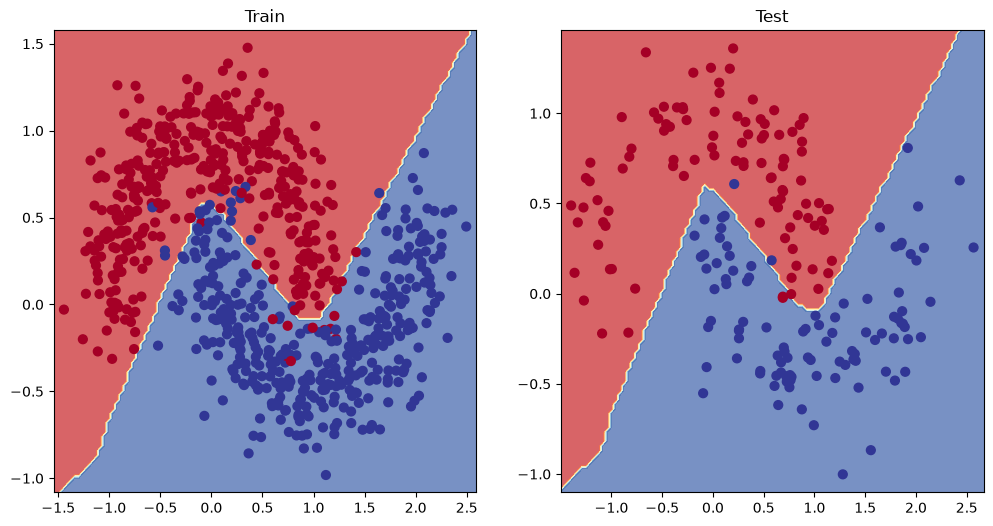

In [264]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_binary, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_binary, X_test, y_test)

In [265]:
N = 100 # number of points per class
D = 2 # dimensionality
F = 2
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

In [266]:
print(f"Shape : {X.shape, y.shape}")
X[:10], y[:10]

Shape : ((300, 2), (300,))


(array([[ 0.        ,  0.        ],
        [ 0.00032023,  0.01009593],
        [ 0.01100285,  0.01694281],
        [-0.00026078,  0.03030191],
        [ 0.0090828 ,  0.0393699 ],
        [ 0.01168731,  0.04913417],
        [ 0.01708541,  0.05814794],
        [-0.00169067,  0.07068686],
        [-0.00584822,  0.08059618],
        [ 0.01845058,  0.08901707]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8))

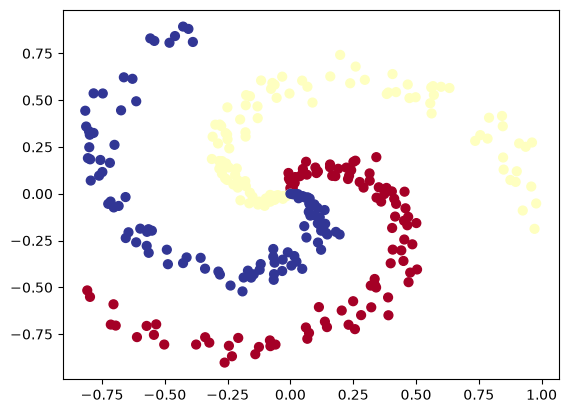

In [267]:
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [268]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

In [269]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(240, 60, 240, 60)

In [270]:
class MultipleClassificationModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_layer=8):
    super().__init__()

    self.linear_layer = nn.Sequential(
      nn.Linear(in_features=input_features, out_features=hidden_layer),
      nn.ReLU(),
      nn.Linear(in_features=hidden_layer, out_features=hidden_layer),
      nn.ReLU(),
      nn.Linear(in_features=hidden_layer, out_features=output_features)
    ).to(device)

  def forward(self, x):
    return self.linear_layer(x)

model_multiple = MultipleClassificationModel(
  input_features=D,
  output_features=K,
  hidden_layer=8
)

model_multiple

MultipleClassificationModel(
  (linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)

In [271]:
accuracy_fn = MulticlassAccuracy(num_classes=K, average='macro').to(device)

In [272]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_multiple.parameters(), lr=0.1)

In [273]:
torch.manual_seed(42)

with torch.inference_mode():
  y_logits = model_multiple(X_test.to(device))
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

# torch.round(torch.sigmoid(y_pred))

y_pred

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')

In [274]:
torch.manual_seed(42)

epochs = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_multiple.train()

  y_logits = model_multiple(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_multiple.eval()

  with torch.inference_mode():
    test_logits = model_multiple(X_test)
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_pred, y_train)

  if epoch % 100 == 0:
    print(f"Epoch : {epoch} | Loss : {loss} | Acc : {acc:.3f}% | Test Loss : {test_loss} | Test Acc : {test_acc:.3f}%")
  

Epoch : 0 | Loss : 1.1025766134262085 | Acc : 0.333% | Test Loss : 1.078005313873291 | Test Acc : 0.333%
Epoch : 100 | Loss : 0.022488627582788467 | Acc : 0.992% | Test Loss : 0.0018489977810531855 | Test Acc : 0.992%
Epoch : 200 | Loss : 0.017620928585529327 | Acc : 0.992% | Test Loss : 0.0008781219366937876 | Test Acc : 0.992%
Epoch : 300 | Loss : 0.016417305916547775 | Acc : 0.992% | Test Loss : 0.001455441233702004 | Test Acc : 0.992%
Epoch : 400 | Loss : 0.01583782397210598 | Acc : 0.991% | Test Loss : 0.00015138016897253692 | Test Acc : 0.991%
Epoch : 500 | Loss : 0.014273077249526978 | Acc : 0.992% | Test Loss : 0.0002262759517179802 | Test Acc : 0.992%
Epoch : 600 | Loss : 0.014715146273374557 | Acc : 0.991% | Test Loss : 0.0001384880015393719 | Test Acc : 0.991%
Epoch : 700 | Loss : 0.014382824301719666 | Acc : 0.992% | Test Loss : 0.000229121811571531 | Test Acc : 0.992%
Epoch : 800 | Loss : 0.014142007566988468 | Acc : 0.991% | Test Loss : 0.0001594583154655993 | Test Acc : 

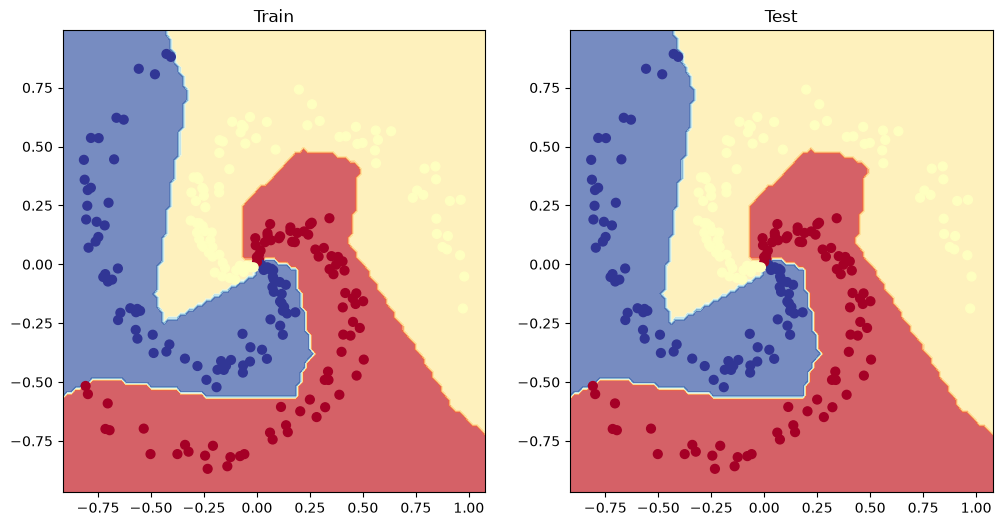

In [275]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_multiple, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_multiple, X_train, y_train)